<a href="https://colab.research.google.com/github/Ammar-2025-k/Mission-True-Love/blob/main/Copy_of_Mission_True_Love.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Mission true love/dating app2(do not edit).csv')
df


Mounted at /content/drive


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,...,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,age,height_cm,weight_kg,zodiac_sign,body_type,relationship_intent
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,...,0.36,13,Early Morning,Mutual Match,56,149,40.6,Taurus,Curvy,Friends Only
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,...,0.42,0,Morning,Chat Ignored,40,155,69.7,Leo,Plus Size,Hookups
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,...,0.41,1,After Midnight,Date Happened,30,185,96.9,Sagittarius,Curvy,Serious Relationship
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,...,0.07,21,Morning,No Action,57,154,49.3,Taurus,Slim,Exploring
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,...,0.11,22,After Midnight,One-sided Like,24,149,40.0,Libra,Slim,Casual Dating
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Transgender,Gay,Metro,Very High,Postdoc,"Gaming, Writing, Painting",130,Addicted,0.69,Optimistic,...,0.19,15,Afternoon,Ghosted,45,195,102.7,Pisces,Plus Size,Casual Dating
49996,Female,Lesbian,Small Town,Low,Diploma,"Traveling, Fitness, Stand-up Comedy",277,Extreme User,0.43,Optimistic,...,0.23,2,Evening,Ghosted,26,185,79.7,Leo,Athletic,Friends Only
49997,Male,Bisexual,Remote Area,High,High School,"Gaming, Motorcycling, Art",73,High,0.50,Optimistic,...,0.36,5,After Midnight,Blocked,45,176,69.1,Pisces,Athletic,Serious Relationship
49998,Transgender,Queer,Urban,Low,MBA,"Skating, Astrology, Hiking",100,High,0.34,Balanced,...,0.36,16,Evening,One-sided Like,29,171,83.6,Libra,Athletic,Friends Only


In [2]:
df.dtypes

,0
gender,object
sexual_orientation,object
location_type,object
income_bracket,object
education_level,object
interest_tags,object
app_usage_time_min,int64
app_usage_time_label,object
swipe_right_ratio,float64
swipe_right_label,object


In [3]:
df.isnull().sum()

,0
gender,0
sexual_orientation,0
location_type,0
income_bracket,0
education_level,0
interest_tags,0
app_usage_time_min,0
app_usage_time_label,0
swipe_right_ratio,0
swipe_right_label,0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Always load from original
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Mission true love/dating app2(do not edit).csv')
print("Fresh copy loaded:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fresh copy loaded: (50000, 25)


In [6]:
columns_to_drop = [
    'zodiac_sign', 'emoji_usage_rate', 'bio_length',
    'app_usage_time_label', 'swipe_time_of_day',
    'swipe_right_label', 'app_usage_time_min'
]
df = df.drop(columns=columns_to_drop)
print("After dropping:", df.shape)

After dropping: (50000, 18)


In [7]:
print("Before:", repr(df['interest_tags'][0]))
df['interest_tags'] = df['interest_tags'].apply(
    lambda x: len(str(x).split(', '))
)
print("After:", df['interest_tags'].value_counts())

Before: 'Fitness, Politics, Traveling'
After: interest_tags
3    50000
Name: count, dtype: int64


In [8]:
true_love_outcomes = ['Mutual Match', 'Relationship Formed',
                      'Date Happened', 'Instant Match']
df['match_outcome'] = df['match_outcome'].isin(true_love_outcomes).astype(int)
print(df['match_outcome'].value_counts())

match_outcome
0    30150
1    19850
Name: count, dtype: int64


In [9]:
# Income bracket
income_order = ['Very Low', 'Low', 'Lower-Middle',
                'Middle', 'Upper-Middle', 'High', 'Very High']
df['income_bracket'] = pd.Categorical(df['income_bracket'],
                       categories=income_order,
                       ordered=True).codes

# Education level
df['education_level'] = df['education_level'].apply(
    lambda x: 0 if 'No Formal' in str(x)
    else 1 if 'High School' in str(x)
    else 2 if 'Diploma' in str(x)
    else 3 if 'Associate' in str(x)
    else 4 if 'Bachelor' in str(x)
    else 5 if 'Master' in str(x)
    else 6 if 'MBA' in str(x)
    else 7 if 'PhD' in str(x)
    else 8 if 'Postdoc' in str(x)
    else -1
)

print(df[['income_bracket', 'education_level']].head())

   income_bracket  education_level
0               5                4
1               4                0
2               1                5
3               0                8
4               3                4


In [10]:
nominal_cols = ['gender', 'sexual_orientation',
                'location_type', 'body_type',
                'relationship_intent']

df = pd.get_dummies(df, columns=nominal_cols)
print("Final shape:", df.shape)

Final shape: (50000, 45)


In [11]:
df.to_csv('/content/drive/MyDrive/Colab Notebooks/Mission true love/checkpoint1_preprocessed.csv', index=False)
print("Checkpoint 1 saved!")

Checkpoint 1 saved!


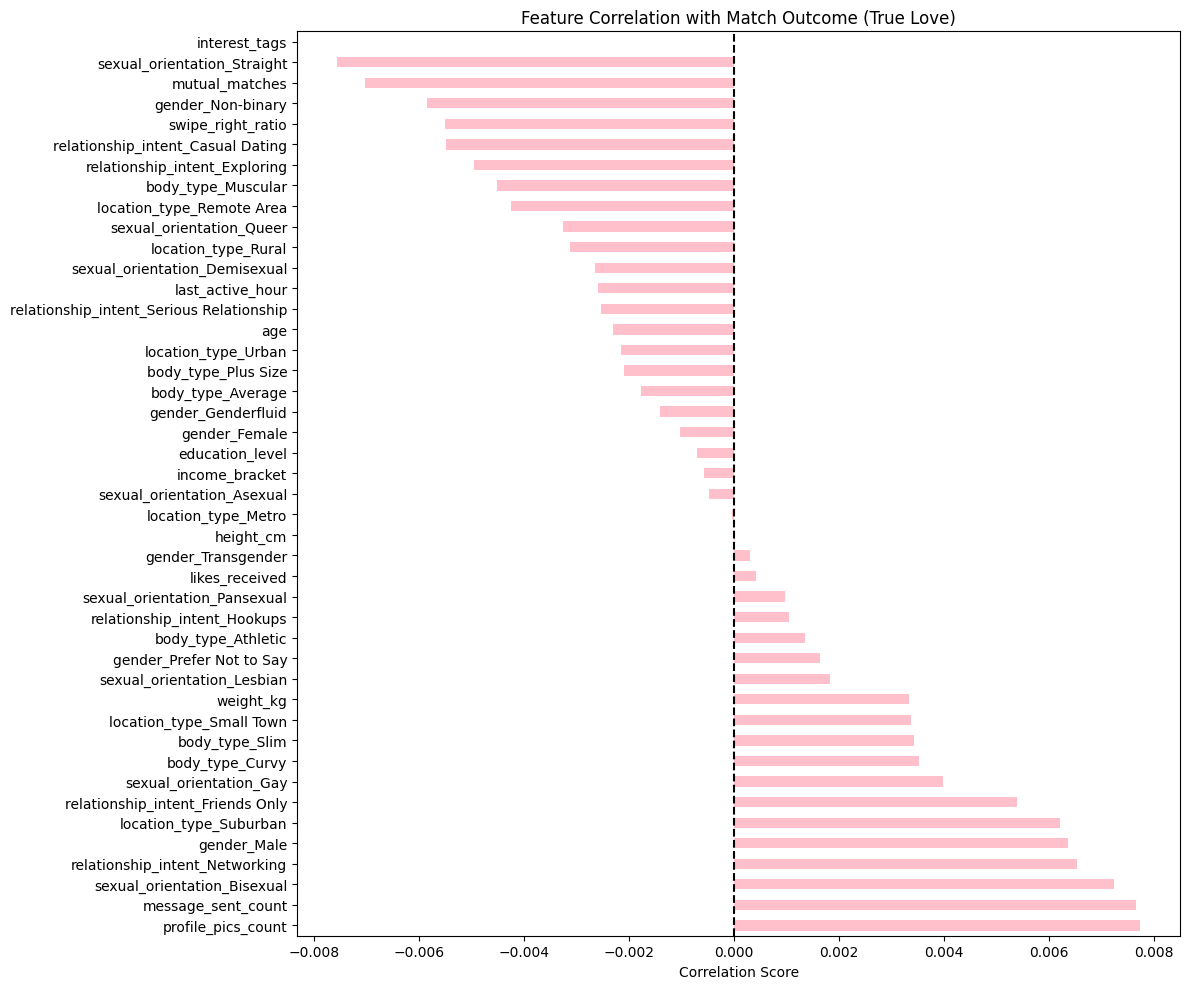

match_outcome                               1.000000
profile_pics_count                          0.007733
message_sent_count                          0.007653
sexual_orientation_Bisexual                 0.007249
relationship_intent_Networking              0.006537
gender_Male                                 0.006360
location_type_Suburban                      0.006207
relationship_intent_Friends Only            0.005392
sexual_orientation_Gay                      0.003986
body_type_Curvy                             0.003523
body_type_Slim                              0.003422
location_type_Small Town                    0.003380
weight_kg                                   0.003341
sexual_orientation_Lesbian                  0.001839
gender_Prefer Not to Say                    0.001646
body_type_Athletic                          0.001359
relationship_intent_Hookups                 0.001050
sexual_orientation_Pansexual                0.000979
likes_received                              0.

In [12]:
#step 4: feature selection
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate correlation with match_outcome
correlation = df.corr()['match_outcome'].sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 10))
correlation.drop('match_outcome').plot(kind='barh', color='pink')
plt.title('Feature Correlation with Match Outcome (True Love)')
plt.xlabel('Correlation Score')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Print values
print(correlation)

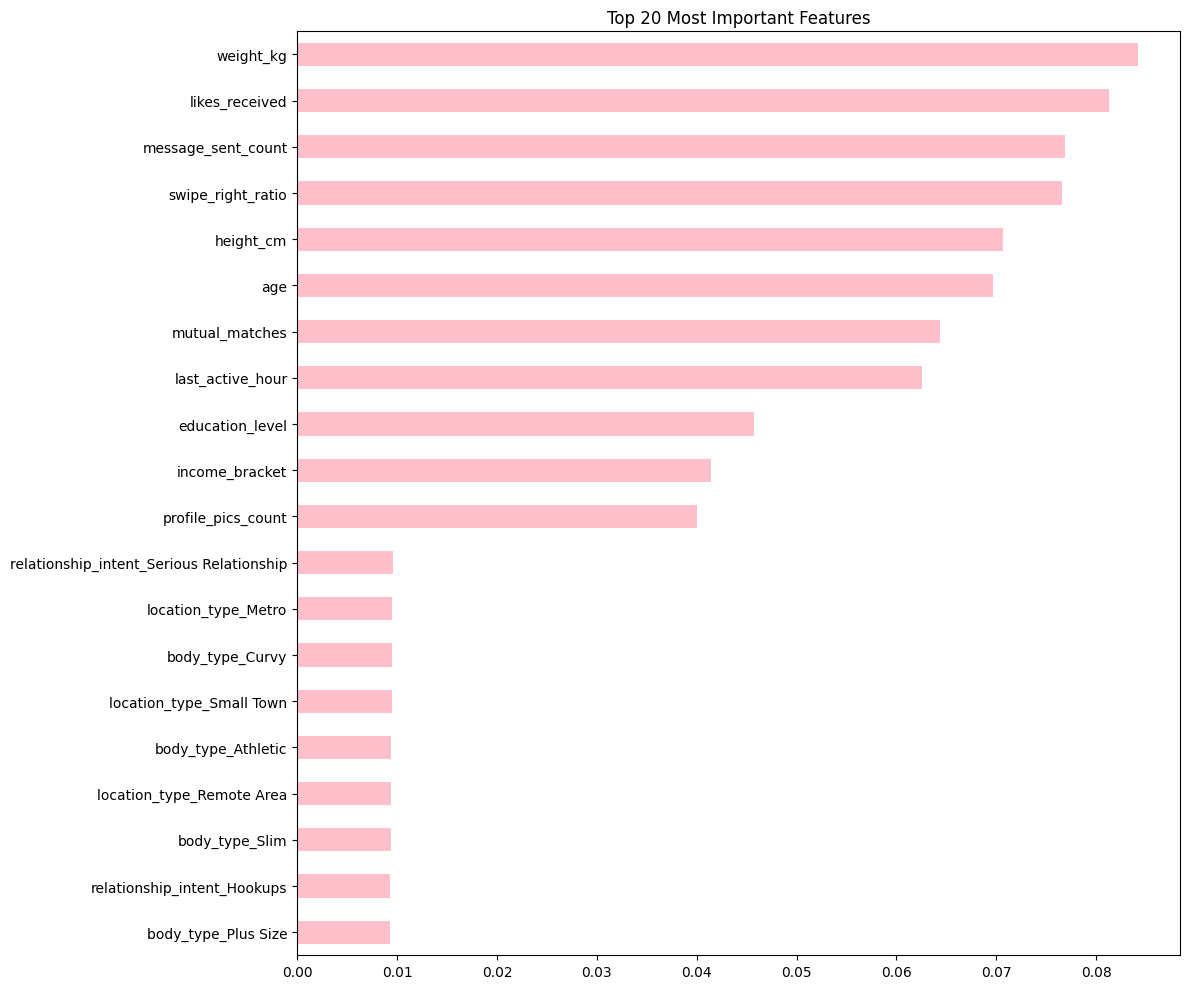

weight_kg                                   0.084186
likes_received                              0.081252
message_sent_count                          0.076886
swipe_right_ratio                           0.076539
height_cm                                   0.070699
age                                         0.069671
mutual_matches                              0.064359
last_active_hour                            0.062519
education_level                             0.045775
income_bracket                              0.041475
profile_pics_count                          0.040011
relationship_intent_Serious Relationship    0.009638
location_type_Metro                         0.009523
body_type_Curvy                             0.009488
location_type_Small Town                    0.009455
body_type_Athletic                          0.009431
location_type_Remote Area                   0.009406
body_type_Slim                              0.009349
relationship_intent_Hookups                 0.

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Separate features and target
X = df.drop(columns=['match_outcome', 'interest_tags'])
y = df['match_outcome']

# Train quick Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Plot feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(12, 10))
importance.head(20).plot(kind='barh', color='pink')
plt.title('Top 20 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.head(20))

In [14]:
#station 5: 1.Logistic Regression 2.Decision Tree 3.Random Forest 4.KNN 5.SVM

In [15]:
#Station 6: Train 5 machine learning model
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['match_outcome'])
y = df['match_outcome']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (40000, 44)
X_test shape: (10000, 44)
y_train shape: (40000,)
y_test shape: (10000,)


In [30]:
# Retraining our models with the optimal hyperparameters AND balanced weights
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

# 1. Logistic Regression
lr_best = LogisticRegression(class_weight='balanced', C=1, penalty='l2', max_iter=1000, random_state=42)

# 2. Decision Tree
dt_best = DecisionTreeClassifier(max_depth=5, min_samples_split=2, random_state=42)

# 3. Random Forest
rf_best = RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=100, random_state=42)

# 4. KNN
knn_best = KNeighborsClassifier(metric='manhattan', n_neighbors=15, weights='uniform')

# 5. SVM
svm_best = LinearSVC(class_weight='balanced', C=0.1, random_state=42)

# Fit all models on the training data so they learn the balanced weights
print("Retraining models with balanced weights...")
lr_best.fit(X_train, y_train)
dt_best.fit(X_train, y_train)
rf_best.fit(X_train, y_train)
knn_best.fit(X_train, y_train)
svm_best.fit(X_train, y_train)
print("All models successfully retrained!")

Retraining models with balanced weights...
All models successfully retrained!


In [17]:
#1. Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
#2. Desicion Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [19]:
#3. Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
#4. KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
#5. SVM
from sklearn.svm import LinearSVC
svm = LinearSVC(random_state=42)
svm.fit(X_train, y_train)
print("SVM trained! ✅")

SVM trained! ✅


In [22]:
#Station 6:  Hyperparameter Tuning
from sklearn.metrics import accuracy_score

# Dictionary of all models
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'KNN': knn,
    'SVM': svm
}

# Check accuracy of each model
print("=" * 45)
print("       BEFORE TUNING — BASELINE ACCURACY")
print("=" * 45)

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:25s}: {acc:.4f} ({acc*100:.2f}%)")

print("=" * 45)

       BEFORE TUNING — BASELINE ACCURACY
Logistic Regression      : 0.5973 (59.73%)
Decision Tree            : 0.5214 (52.14%)
Random Forest            : 0.5896 (58.96%)
KNN                      : 0.5410 (54.10%)
SVM                      : 0.5973 (59.73%)


In [23]:
from sklearn.model_selection import GridSearchCV

# 1. Logistic Regression Tuning
print("Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)
print(f"Best params: {lr_grid.best_params_}")
print(f"Best accuracy: {lr_grid.best_score_:.4f}")
print()

Tuning Logistic Regression...
Best params: {'C': 0.01, 'solver': 'lbfgs'}
Best accuracy: 0.6044



In [24]:
from sklearn.tree import DecisionTreeClassifier

# 2. Decision Tree Tuning
print("Tuning Decision Tree...")
dt_params = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print(f"Best params: {dt_grid.best_params_}")
print(f"Best accuracy: {dt_grid.best_score_:.4f}")
print()

Tuning Decision Tree...
Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best accuracy: 0.6042



In [25]:
from sklearn.ensemble import RandomForestClassifier

# 3. Random Forest Tuning
print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"Best params: {rf_grid.best_params_}")
print(f"Best accuracy: {rf_grid.best_score_:.4f}")
print()

Tuning Random Forest...
Best params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best accuracy: 0.6045



In [26]:
from sklearn.neighbors import KNeighborsClassifier

# 4. KNN Tuning
print("Tuning KNN...")
knn_params = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}
knn_grid = GridSearchCV(KNeighborsClassifier(),
                        knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
print(f"Best params: {knn_grid.best_params_}")
print(f"Best accuracy: {knn_grid.best_score_:.4f}")
print()

Tuning KNN...
Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best accuracy: 0.5645



In [27]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV

# Faster SVM Tuning using LinearSVC
print("Tuning SVM (Fast version)...")
svm_params = {
    'C': [0.01, 0.1, 1, 10],
    'max_iter': [1000, 2000]
}
svm_grid = GridSearchCV(LinearSVC(random_state=42),
                        svm_params, cv=5, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)
print(f"Best params: {svm_grid.best_params_}")
print(f"Best accuracy: {svm_grid.best_score_:.4f}")

Tuning SVM (Fast version)...
Best params: {'C': 0.01, 'max_iter': 1000}
Best accuracy: 0.6044


In [28]:
from sklearn.svm import LinearSVC

# Retrain all models with best parameters
lr_best = LogisticRegression(C=0.01, solver='lbfgs',
                             max_iter=1000, random_state=42)
lr_best.fit(X_train, y_train)

dt_best = DecisionTreeClassifier(criterion='gini', max_depth=3,
                                 min_samples_split=2, random_state=42)
dt_best.fit(X_train, y_train)

rf_best = RandomForestClassifier(max_depth=10, min_samples_split=5,
                                 n_estimators=200, random_state=42)
rf_best.fit(X_train, y_train)

knn_best = KNeighborsClassifier(metric='manhattan',
                                n_neighbors=15, weights='uniform')
knn_best.fit(X_train, y_train)

svm_best = LinearSVC(C=0.01, max_iter=1000, random_state=42)
svm_best.fit(X_train, y_train)

print("All 5 models retrained with best parameters! ✅")

All 5 models retrained with best parameters! ✅


In [31]:
# Station 7 — Fixed Formatting and Safe Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_models = {
    'Logistic Regression': lr_best,
    'Decision Tree': dt_best,
    'Random Forest': rf_best,
    'KNN': knn_best,
    'SVM': svm_best
}

# Adjusted spacing so everything fits neatly on shorter screen widths
print("=" * 65)
print(f"{'Model':20s} {'Acc':8s} {'Prec':8s} {'Rec':8s} {'F1':8s}")
print("=" * 65)

results = {}
for name, model in best_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    }

    # Using 8-character spacing for numbers to keep them perfectly aligned
    print(f"{name:20s} {acc:.4f}   {prec:.4f}   {rec:.4f}   {f1:.4f}")

print("=" * 65)

Model                Acc      Prec     Rec      F1      
Logistic Regression  0.5020   0.4044   0.5006   0.4474
Decision Tree        0.5959   0.3750   0.0052   0.0103
Random Forest        0.5399   0.4141   0.3437   0.3756
KNN                  0.5584   0.4046   0.2049   0.2720
SVM                  0.5024   0.4047   0.5006   0.4476
